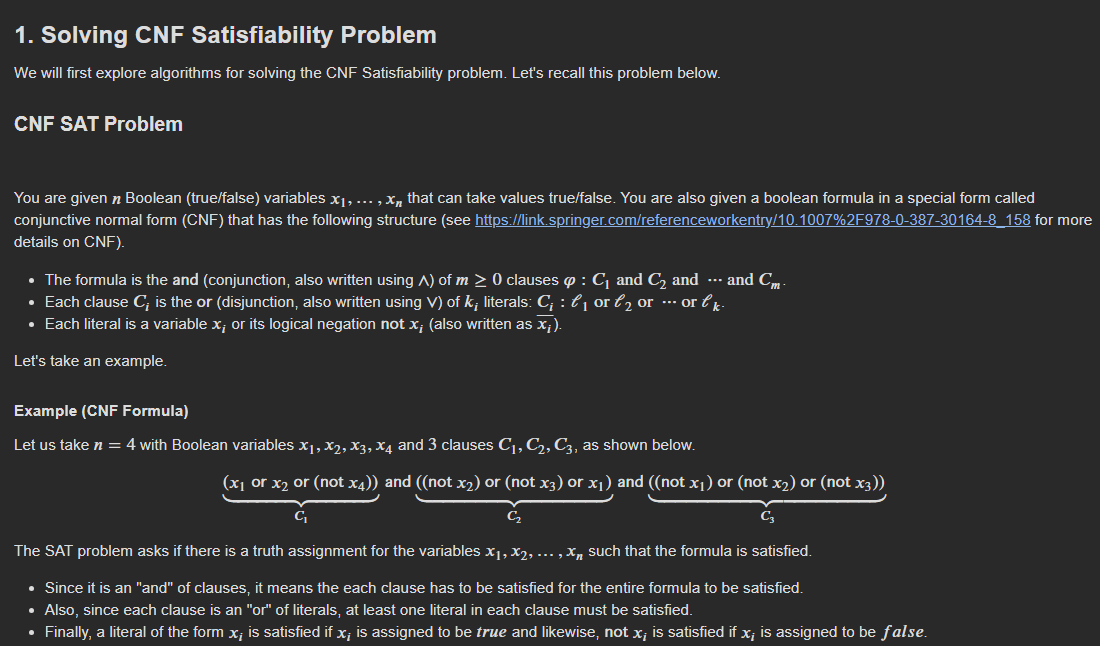

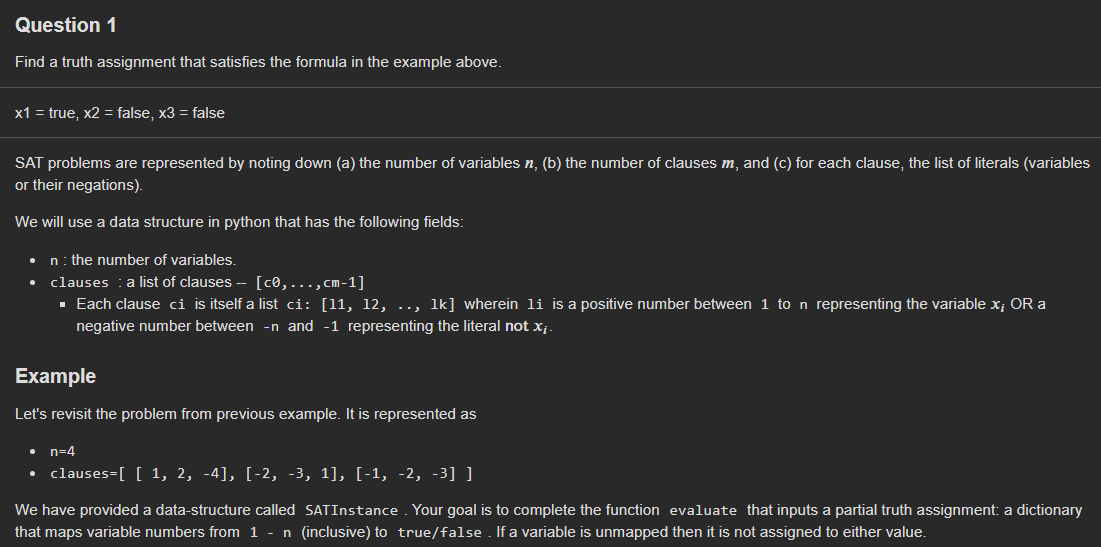
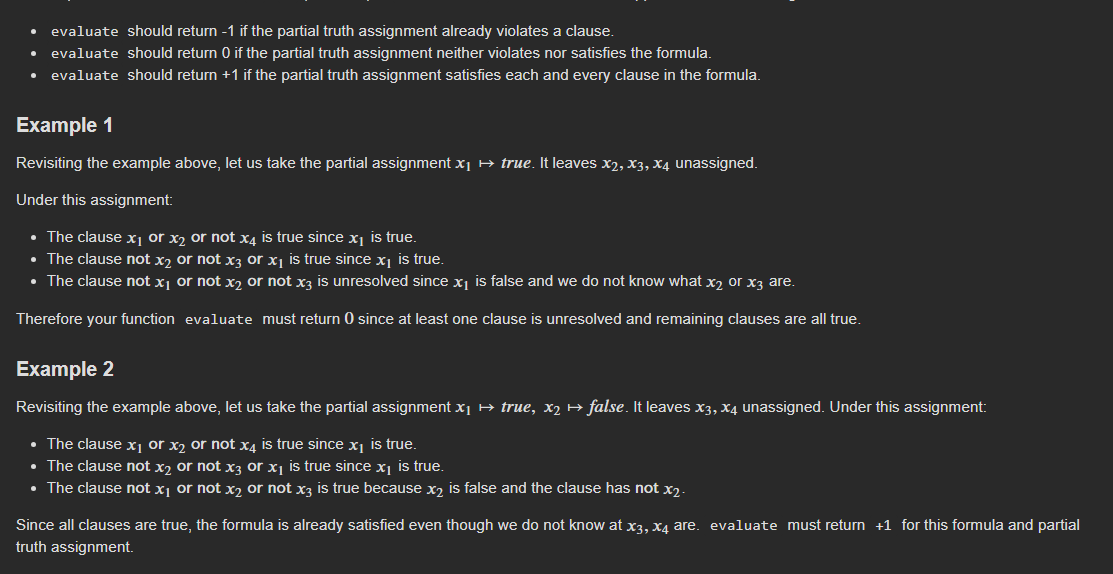
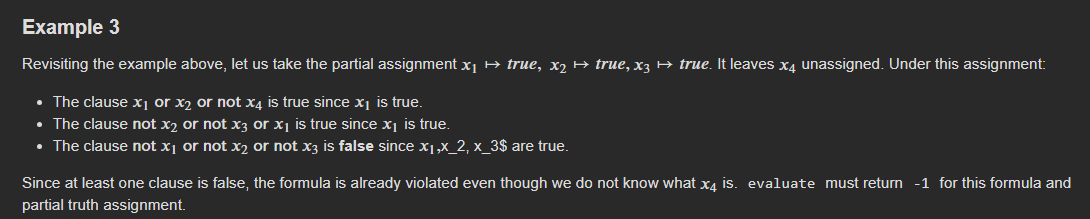

In [48]:
class SATInstance:
    # Constructor: provide n the number of variables and
    # an initial list of clauses.
    # Note that variable numbers will go from 1 to n inclusive.
    # we can add clauses using the add_clause method.
    def __init__(self, n, clauses):
        self.n = n
        self.m = len(clauses)
        self.clauses = clauses
        assert self.is_valid()
    # is_valid
    # Check if all clauses are correct.
    # literals in each clause must be between 1 and n or -n and -1 
    def is_valid(self):
        assert self.n >= 1
        assert self.m >= 0
        for c in self.clauses:
            for l in c:
                assert (1 <= l and l <= self.n) or (-self.n <= l and l <= -1)
        return True
    
    # add_clause
    # Add a new clause to the list of clauses
    def add_clause(self, c):
        #check the clause we are adding.
        for l in c:
            if(not ((1 <= l and l <= self.n) or (-self.n <= 1 and l <= -1))):
                print(f'invalid value for cluase ={l}')
            assert (1 <= l and l <= self.n) or (-self.n <= 1 and l <= -1)
        self.clauses.append(c)
    
    ## Function: evaluate_literal
    # Evaluate a literal against a partial truth assignment
    # return 0 if the partial truth assignment does not have the variable corresponding to the literal
    # return 1 if the partial truth assignment has the variable and the literal is true
    # return -1 if the partial truth assignment has the variable and the literal is false
    def evaluate_literal(self, partial_truth_assignment, literal):
        var = abs(literal) # literal may be negated. First remove any negation using abs
        if var not in partial_truth_assignment:
            return 0
        v = partial_truth_assignment[var]
        if 1 <= literal <= self.n:
            return 1 if v else -1
        else:
            return -1 if v else 1
    
    ## TODO: Write your code here
    # Function: evaluate
    # See description above: partial_truth_assignment is a dictionary from 1 .. n to true/false.
    # since it is partial, we may have variables with no truth assignments.
    # use evaluate_literal function as a useful primitive
    # return +1 if the formula is already satisfied under partial_truth_assignment: i.e, all clauses are true
    # return 0 if formula is indeterminate under partial_truth_assignment, all clauses are true or unresolved and at least one clause is unresolved.
    # return -1 if formula is already violated under partial_truth_assignment, i.e, at least one clause is false
    def evaluate(self, partial_truth_assignment):
        # your code here
        for c in self.clauses:
            unknown_exists = False
            one_true_exists = False
            for l in c:
                literal_result = self.evaluate_literal(partial_truth_assignment, l)
                if 0==literal_result:
                    unknown_exists = True
                elif 1==literal_result:
                    one_true_exists = True
            if((not one_true_exists) and unknown_exists): # current clause  evaluates to unknown
                return 0
            elif((not one_true_exists) and (not unknown_exists)): # current clause  evaluates to false
                return -1
        return 1 # all clauses evaluated to true
        
        
        

In [2]:
## BEGIN TESTS

print('-test1-')
f1 = SATInstance(4, [ [ 1, 2, -4], [-2, -3, 1], [-1, -2, -3] ])
t1 = {1:True, 2:False}
e1 = f1.evaluate(t1)
assert e1 == 1, f'Expected that f1 is satisfied by t1 but your code returns: {e1}'

print('-test2-')
t2 = {1:False, 2: False}
e2 = f1.evaluate(t2)
assert e2 == 0, f'Expected that f1 is indeterminate under t2. Your code returns: {e2}'

print('-test3-')
f2 = SATInstance(5, [[1,2,-5],[-4,-2,-1], [1, 3, 5], [-1, -5, -2], [1, 2, -4]])
t3 = {1:True}
e3 = f2.evaluate(t3)
assert e3 == 0, f'Expected that f2 is indeterminate under t3. Your code returns {e3}' 

print('-test4-')
t4 = {1: True, 2: False}
e4 = f2.evaluate(t4)
assert e4 == 1, f'Expected that f2 is satisfied by t4. Your code returns {e4}'

print('-test5-')
t5 = {1: False, 3: False, 5:False}
e5 = f2.evaluate(t5)
assert e5 == -1, f'Expected that f2 is violated by t5. Your code returns {e5}'
print('All tests passed: 10 points!')
## END TESTS

-test1-
-test2-
-test3-
-test4-
-test5-
All tests passed: 10 points!


# DPLL recursive algorithm to find truth assignments -  brute force - toggle true/false on all of the assignments
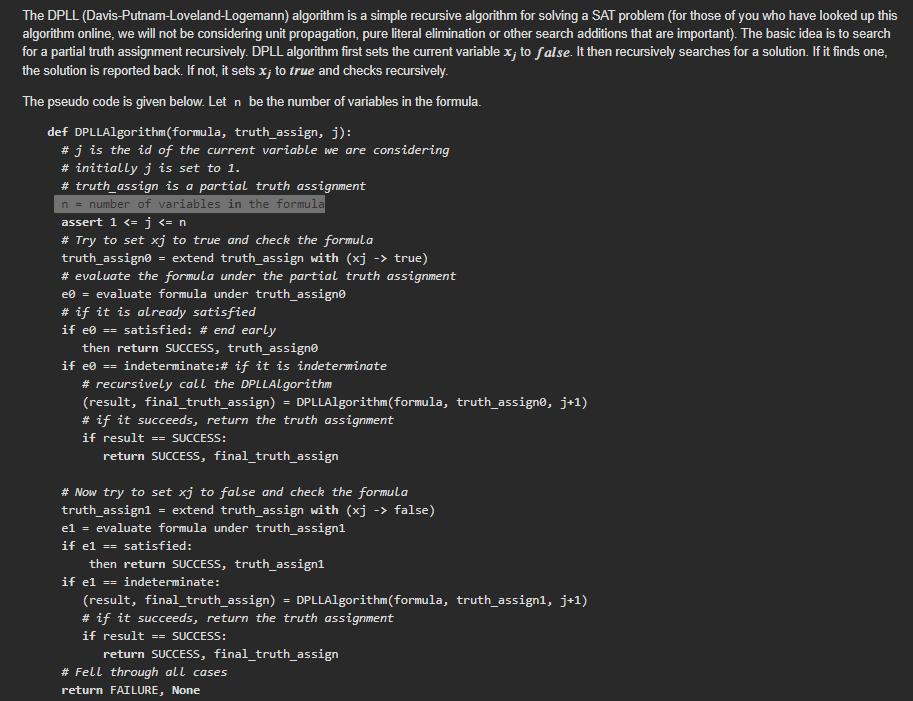

In [17]:
def extend_truth_assignment(truth_assign, j, b):
    truth_assign[j] = b
    return truth_assign
    
def forget_var_in_truth_assign(truth_assign, j):
    # remove variable from a dictionary
    if j in truth_assign:
        del truth_assign[j]
    return truth_assign

# Implement the DPLL pseudo code with the following modifications
#   return (True, partial_truth_assignment) if the formula is satisfiable
#   return (False, None) if the formula is unsatisfiable. 
# You may use the extend_truth_assignment and forget_var_in_truth_assign functions.
# Remember that a change in a dictionary is reflected back to the caller and this is important to keep in mind.
# Use the evaluate function in SATInstance class to evaluate a formula under partial truth assignment.
def dpll_algorithm(formula, partial_truth_assign, j):
    # print("j is "+str(j))
    # print(f'truth assgnment is {partial_truth_assign}' )
    if j == ((formula.n)+1):
        # print("end of recursion")
        return (False, None)
    assert 1 <= j and j <= formula.n
    assert j not in partial_truth_assign
    #  flip the current variable to 'true' and execute code to see the evaluation status
    partial_truth_assign[j] = True
    res = formula.evaluate(partial_truth_assign)
    if(1 == res):
        return (True, partial_truth_assign)
    if(0 == res):
        (result, final_assignment) = dpll_algorithm(formula, partial_truth_assign, j+1)
        if(1 == result):
            return (True, final_assignment)
        
    #  flip the current variable to 'false' and execute same code
    partial_truth_assign[j] = False
    res = formula.evaluate(partial_truth_assign)
    if(1 == res):
        return (True, partial_truth_assign)
    if(0 == res):
        (result, final_assignment) = dpll_algorithm(formula, partial_truth_assign, j+1)
        if(1 == result):
            return (True, final_assignment)
    
    #since both true and false failed for current variable, delete it from assignments (its status will be undefined and it will roll to one level up in stack)
    forget_var_in_truth_assign(partial_truth_assign, j)
    return False, None

def solve_formula(formula):
    return dpll_algorithm(formula, {}, 1)


In [18]:
print('-- formula 1 --')
f1 = SATInstance(4, [ [ 1, 2, -4], [-2, -3, 1], [-1, -2, -3] ])
(e, t) = solve_formula(f1)
print(e, t)
assert e, 'f1 should be satisfiable'
assert t != None, 'does not return a truth assignment'
assert f1.evaluate(t) == 1, 'Truth assignment does not evaluate to expected value of true'

print('-- formula 2 -- ')
f2 = SATInstance(5, [[1,2,-5],[-4,-2,-1], [1, 3, 5], [-1, -5, -2], [1, 2, -4]])
(e2, t2) = solve_formula(f2)
print(e2, t2)
assert e2, 'f2 must be satisfiable'
assert t2 != None, 'does not return a truth assignment'
assert f2.evaluate(t2) == 1, 'Truth assignment does not evaluate to expected value of true'

print('--formula 3 --')
f3 = SATInstance(5, [[1, 2, -5, -4], [1, 2, -5, 4], [-1], [-2,-5], [5]])
(e3, t3) = solve_formula(f3)
print(e3, t3)
assert not e3, 'f3 is unsatisfiable'
assert t3 == None

print('--formula 4--')
f4 = SATInstance(10, [
  [-1, -5, -4, 8],
  [1, 5, 8, 2],
   [2, 1, 3, 9],
    [-2, 4, 5, 6, -7],
    [-1, 2, -1, 7, 8],
    [2, -3, 1, 4, 9 ],
    [1, 10],
    [-10],
    [1, 5, 8, 3, 10]
])

(e4, t4) = solve_formula(f4)
print(e4, t4)
assert e4, 'f4 must be satisfiable'
assert t4 != None, 'does not return a truth assignment'
assert f4.evaluate(t4) == 1, 'Truth assignment does not evaluate to expected value of true'

print('--formula 5--')
f5 = SATInstance(16,[
     [1, 2], [-2 , -4],[3, 4], [-4, -5], [5, -6], [6, -7], [6, 7], [7, -16],
     [8, -9],[8, -14], [9, 10], [9, -10], [-10, -11], [10, 12], [11, 12], [13, 14],
     [14, -15], [15, 16]])
(e5, t5) = solve_formula(f5)
print(e5, t5)
assert e5, 'f5 is satisfiable'
assert t5 != None
assert f5.evaluate(t5) == 1, 'Truth assignment does not evaluate to expected value of true'

print('All tests passed: 20 points')

-- formula 1 --
True {1: True, 2: True, 3: False}
-- formula 2 -- 
True {1: True, 2: True, 3: True, 4: False, 5: False}
--formula 3 --
False None
--formula 4--
True {1: True, 2: True, 3: True, 4: True, 5: True, 6: True, 7: True, 8: True, 9: True, 10: False}
--formula 5--
True {1: True, 2: True, 3: True, 4: False, 5: True, 6: True, 7: True, 8: True, 9: True, 10: True, 11: False, 12: True, 13: True, 14: True, 15: True}
All tests passed: 20 points


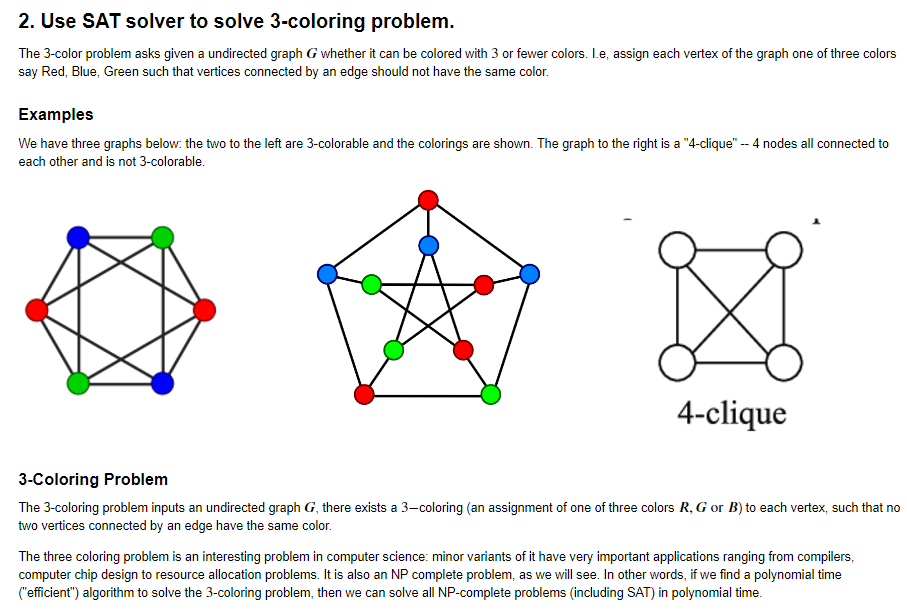

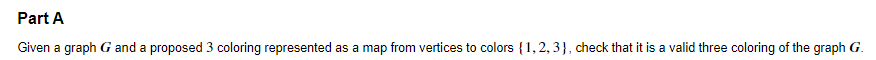

In [23]:
class UndirectedGraph:
    # n_verts: number of vertices of the graph
    #   vertices are labeled from 0... n-1
    # adj_list: an adjacency list represented as a list of lists.
    #  if set to None, we will initialize it as an empty graph
    def __init__(self, n_verts, adj_list=None):
        self.n = n_verts
        if adj_list == None:
            adj_list = [ [] for j in range(self.n)] # initialize as empty list of lists
        else:
            assert len(self.adj_list) == n_verts
            for lst in adj_list:
                for elt in lst:
                    assert 0 <= elt and elt < self.n_verts
        
        self.adj_list = adj_list
    
    def add_edge(self, i, j):
        assert 0 <= i and i < self.n
        assert 0 <= j and j < self.n
        assert i != j
        self.adj_list[i].append(j)
        self.adj_list[j].append(i)
        
    def get_list_of_edges(self):
        return [ (i, j) for i in range(self.n) for j in self.adj_list[i] if i < j ]
    #  i < j because we need to evaluate edge only once for coloring (A->B is same as B<-A)
        
  

In [26]:
def is_three_coloring(graph, coloring):
    n = graph.n
    for i in range(n):
        if i not in coloring:
            return False # every vertex must receive a color
        if coloring[i] < 1 or coloring[i] > 3:
            return False # coloring must be between 1 and 3 inclusive
    # Your code should complete the check below
    # use the provided function graph.get_list_of_edges() to get a list of edges
    # or feel free to extend the graph data structure as you will.
    # your code here
    edges = graph.get_list_of_edges()
    for (i,j) in edges:
        if coloring[i] == coloring[j]:
            return False
    return True

In [27]:
print('--- Test 1 ---')
g1 = UndirectedGraph(5)
g1.add_edge(0, 1)
g1.add_edge(1, 2)
g1.add_edge(2, 0)
g1.add_edge(1, 3)
g1.add_edge(3, 4)
g1.add_edge(1, 4)
g1.add_edge(4,0)


coloring1 = {0:1, 1:2, 2:3, 3:1, 4: 3}
assert is_three_coloring(g1, coloring1), 'Test 1 fail: Coloring should be valid of g1.'

print('--- Test 2 ---')
g2 = UndirectedGraph(7)
g2.add_edge(2, 3)
g2.add_edge(2, 1)
g2.add_edge(2, 0)
g2.add_edge(2, 4)
g2.add_edge(3, 5)
g2.add_edge(3, 6)
g2.add_edge(5, 6)
g2.add_edge(1, 0)
g2.add_edge(1, 4)
g2.add_edge(0, 4)

coloring2 = {2: 1, 3: 2, 4: 2, 0: 1, 1: 3, 5: 3, 6: 1}

assert not is_three_coloring(g2, coloring2), 'Test 2 fail: Coloring should be not be valid of g2.'


print('-- Test 3 --- ')

coloring3 = {2: 3, 3: 2, 4: 2, 0: 2, 1: 1, 5: 3, 6: 1}

assert not is_three_coloring(g2, coloring3), 'Test 3 fail: Coloring should be not be valid of g2.' 

print('All Tests Passed (10 points)!') 

--- Test 1 ---
--- Test 2 ---
-- Test 3 --- 
All Tests Passed (10 points)!


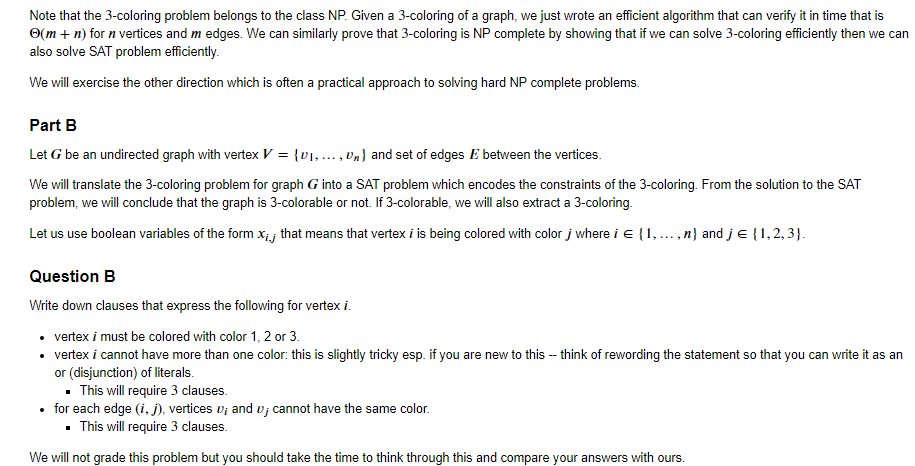

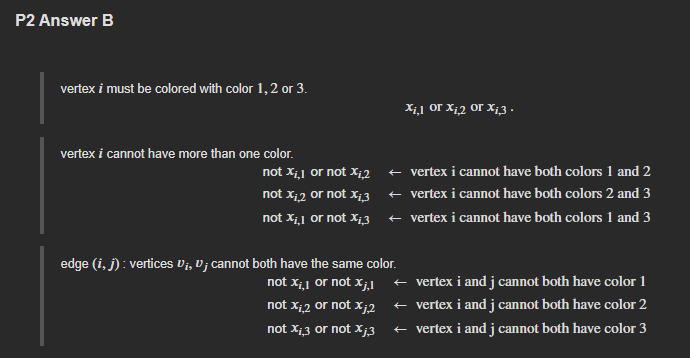

In [50]:
# Implement the Translation
# Let's use the SATInstance class from the previous problem and the SAT solver we constructed to solve the 3-coloring problem.

# Input: a graph that is an instance of the `UndirectedGraph` class
# Output: an instance of `SATInstance` that encodes the 3 coloring problem
# Useful functions:
#   SATInstance class add_clause
#   UndirectedGraph class get_list_of_edges 
def translate_three_coloring(graph):
    n_boolean_vars = graph.n * 3 # 3 boolean variables for each vertex
    print(f'n_boolean_vars={n_boolean_vars}')
    # You can define your own scheme for translating x_i,j into the index of a prop. var.
    # we propose using x_i,j --> 3 *i + j
    s = SATInstance(n_boolean_vars, []) # no clauses
    # your code here
    # clause for each vertex must be colored 1,2 or 3
    c1 = [ [3*i+1,3*i+2,3*i+3] for i in range(graph.n) ]
    # clause for each vertex cannot have more than one color
    c2 = [ [-(3*i+x), -(3*i+y)] for i in range(graph.n) for x in range(1,3) for y in range(x+1,4) ]
    # clause for each edge cannot end vertices of same color
    edges = graph.get_list_of_edges()
    c3 = [ [-(3*i +y), -(3*j+y)] for(i,j) in edges for y in range(1,4)]
    all_clauses = c1 + c2 + c3
    print(f'{all_clauses}')
    for c in all_clauses:
        s.add_clause(c)
    return s


# Input: graph --> an instance of UndirectedGraph with n vertices
#         truth_assign --> dictionary with key in range 1 ... 3*n mapping each key to true/false
#                           output from SAT solver.
# Output: A dictionary mapping vertices 0,..., n-1 to colors {1, 2, 3}   
# This function will be implemented based on the scheme you used in previous function translate_three_coloring
def extract_graph_coloring_from_truth_assignment(graph, truth_assign):
    # your code here
    colorOfVertices = {}
    for i in range(graph.n):
        colorOfVertices[i] = 1 if truth_assign[3*i+1] else 2 if truth_assign[3*i+2] else 3
    return colorOfVertices


def solve_three_coloring(graph):
    s = translate_three_coloring(graph)
    print(s.clauses)
    res, truth_assign = solve_formula(s)
    print(res)
    print(truth_assign)
    if res: 
        return extract_graph_coloring_from_truth_assignment(graph, truth_assign)
    else: 
        return None

In [52]:
print('--- Test 0 ---')
# A simple triangle should be 3 colorable
g0 = UndirectedGraph(3)
g0.add_edge(0,1)
g0.add_edge(1,2)
g0.add_edge(0,2)
coloring = solve_three_coloring(g0)
print(coloring)
assert coloring != None
assert is_three_coloring(g0, coloring)
print('Passed')

print('-- Test 1 --')
# The "complete" graph on 4 vertices is not 3 colorable
g1 = UndirectedGraph(4)
g1.add_edge(0, 1)
g1.add_edge(0, 2)
g1.add_edge(0, 3)
g1.add_edge(1, 2)
g1.add_edge(1, 3)
g1.add_edge(2, 3)
coloring = solve_three_coloring(g1)
assert coloring == None 
print('Passed')

print('--Test 2--')
# Make a chordal graph on 6 vertices
g2 = UndirectedGraph(6)
# make a 6 cycle
g2.add_edge(0, 1)
g2.add_edge(1, 2)
g2.add_edge(2, 3)
g2.add_edge(3, 4)
g2.add_edge(4, 5)
# add two chords
g2.add_edge(0, 3)
g2.add_edge(2, 4)
coloring = solve_three_coloring(g2)
print(coloring)
assert coloring != None
assert is_three_coloring(g2, coloring)
print('Passed')

print('-- Test 3 --')
g2.add_edge(1,3)
g2.add_edge(0, 2)
coloring = solve_three_coloring(g2)
print(coloring)
assert (coloring == None)
print('Passed')


print('--- Test 4 ---')
g1 = UndirectedGraph(5)
g1.add_edge(0, 1)
g1.add_edge(1, 2)
g1.add_edge(2, 0)
g1.add_edge(1, 3)
g1.add_edge(3, 4)
g1.add_edge(1, 4)
g1.add_edge(4, 0)
coloring = solve_three_coloring(g1)
print(coloring)
assert is_three_coloring(g1, coloring) 
print('Passed')

print('-- Test 5 -- ')

g2 = UndirectedGraph(7)
g2.add_edge(2, 3)
g2.add_edge(2, 1)
g2.add_edge(2, 0)
g2.add_edge(2, 4)
g2.add_edge(3, 5)
g2.add_edge(3, 6)
g2.add_edge(5, 6)
g2.add_edge(1, 0)
g2.add_edge(1, 4)

coloring = solve_three_coloring(g2)
print(coloring)
assert  is_three_coloring(g2, coloring)
print('Passed')

print('--Test 6--')
g2.add_edge(0, 4)
coloring = solve_three_coloring(g2)
assert coloring == None
print('passed')

print('All test passed: 15 points!')

--- Test 0 ---
n_boolean_vars=9
[[1, 2, 3], [4, 5, 6], [7, 8, 9], [-1, -2], [-1, -3], [-2, -3], [-4, -5], [-4, -6], [-5, -6], [-7, -8], [-7, -9], [-8, -9], [-1, -4], [-2, -5], [-3, -6], [-1, -7], [-2, -8], [-3, -9], [-4, -7], [-5, -8], [-6, -9]]
[[1, 2, 3], [4, 5, 6], [7, 8, 9], [-1, -2], [-1, -3], [-2, -3], [-4, -5], [-4, -6], [-5, -6], [-7, -8], [-7, -9], [-8, -9], [-1, -4], [-2, -5], [-3, -6], [-1, -7], [-2, -8], [-3, -9], [-4, -7], [-5, -8], [-6, -9]]
True
{1: True, 2: False, 3: False, 4: False, 5: True, 6: False, 7: False, 8: False, 9: True}
{0: 1, 1: 2, 2: 3}
Passed
-- Test 1 --
n_boolean_vars=12
[[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [-1, -2], [-1, -3], [-2, -3], [-4, -5], [-4, -6], [-5, -6], [-7, -8], [-7, -9], [-8, -9], [-10, -11], [-10, -12], [-11, -12], [-1, -4], [-2, -5], [-3, -6], [-1, -7], [-2, -8], [-3, -9], [-1, -10], [-2, -11], [-3, -12], [-4, -7], [-5, -8], [-6, -9], [-4, -10], [-5, -11], [-6, -12], [-7, -10], [-8, -11], [-9, -12]]
[[1, 2, 3], [4, 5, 6], [7, 